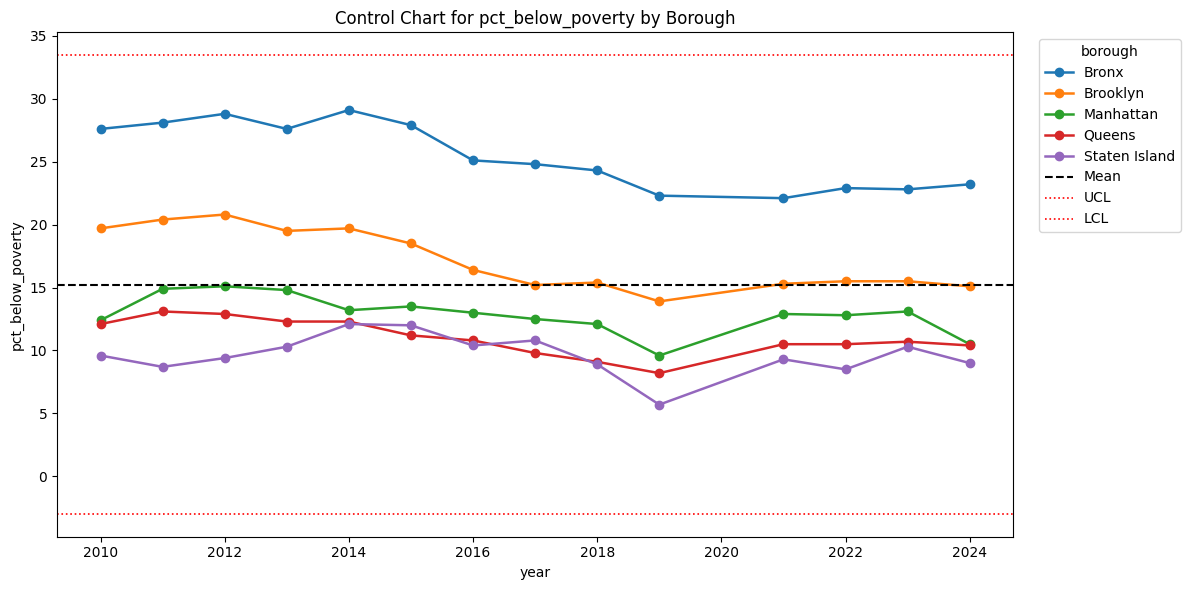

In [1]:
# Consolidated imports
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "data_csv/ACS_socioeconomic_indicators_2010-2024_Data"

if os.path.isdir(path):
    csv_files = sorted(glob.glob(os.path.join(path, "*.csv")))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {path}")
    csv_path = csv_files[0]
else:
    csv_path = path if os.path.exists(path) else f"{path}.csv"

df = pd.read_csv(csv_path)

borough_col = next((c for c in df.columns if c.lower() in {"borough", "boro", "borough_name"}), None)
if borough_col is None:
    object_cols = df.select_dtypes(include="object").columns.tolist()
    if not object_cols:
        raise ValueError("No borough column found.")
    borough_col = object_cols[0]

value_col = next((c for c in df.columns if c.lower() == "pct_below_poverty"), None)
if value_col is None:
    candidates = [c for c in df.columns if "poverty" in c.lower()]
    if not candidates:
        raise ValueError("No pct_below_poverty column found.")
    value_col = candidates[0]

time_col = next((c for c in df.columns if c.lower() in {"year", "date", "month", "period", "time"}), None)

plt.figure(figsize=(12, 6))

for borough, grp in df.groupby(borough_col, dropna=False):
    grp = grp.copy()
    if time_col is not None:
        grp = grp.sort_values(time_col)
        x = grp[time_col]
    else:
        x = range(len(grp))
    plt.plot(x, grp[value_col], marker="o", linewidth=1.8, label=str(borough))

overall_mean = df[value_col].mean()
overall_std = df[value_col].std(ddof=1)
ucl = overall_mean + 3 * overall_std
lcl = overall_mean - 3 * overall_std

plt.axhline(overall_mean, color="black", linestyle="--", linewidth=1.5, label="Mean")
plt.axhline(ucl, color="red", linestyle=":", linewidth=1.2, label="UCL")
plt.axhline(lcl, color="red", linestyle=":", linewidth=1.2, label="LCL")

plt.title("Control Chart for pct_below_poverty by Borough")
plt.xlabel(time_col if time_col is not None else "Observation")
plt.ylabel("pct_below_poverty")
plt.legend(title=borough_col, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [2]:
asthma_path = "data_csv/merged_asthma_data.csv"
asthma_df = pd.read_csv(asthma_path)

asthma_year_col = next((c for c in asthma_df.columns if c.lower() in {"year", "date", "time", "period"}), None)
asthma_borough_col = next((c for c in asthma_df.columns if c.lower() in {"borough", "boro", "borough_name"}), None)
asthma_rate_col = next((c for c in asthma_df.columns if "asthma_incidence_rate" in c.lower()), None)

if asthma_year_col is None or asthma_borough_col is None or asthma_rate_col is None:
    raise ValueError("Could not find year, borough, or asthma_incidence_rate columns in merged_asthma_data.csv")

acs_subset = df[[time_col, borough_col, "median_hh_income"]].copy()
asthma_subset = asthma_df[[asthma_year_col, asthma_borough_col, asthma_rate_col]].copy()

acs_subset[borough_col] = acs_subset[borough_col].astype(str).str.strip().str.lower()
asthma_subset[asthma_borough_col] = asthma_subset[asthma_borough_col].astype(str).str.strip().str.lower()

merged_corr = pd.merge(
    asthma_subset.rename(columns={asthma_year_col: "year", asthma_borough_col: "borough", asthma_rate_col: "asthma_incidence_rate"}),
    acs_subset.rename(columns={time_col: "year", borough_col: "borough"}),
    on=["year", "borough"],
    how="inner"
).dropna(subset=["asthma_incidence_rate", "median_hh_income"])

corr_value = merged_corr["asthma_incidence_rate"].corr(merged_corr["median_hh_income"])

print(f"Pearson correlation between asthma_incidence_rate and median_hh_income: {corr_value:.4f}")
display(merged_corr.head())

Pearson correlation between asthma_incidence_rate and median_hh_income: -0.8201


,year,borough,asthma_incidence_rate,median_hh_income
0,2010,bronx,670.317173,32568
1,2010,brooklyn,307.653667,42143
2,2010,manhattan,237.537326,63832
3,2010,queens,208.609297,53054
4,2010,staten island,198.566994,70560


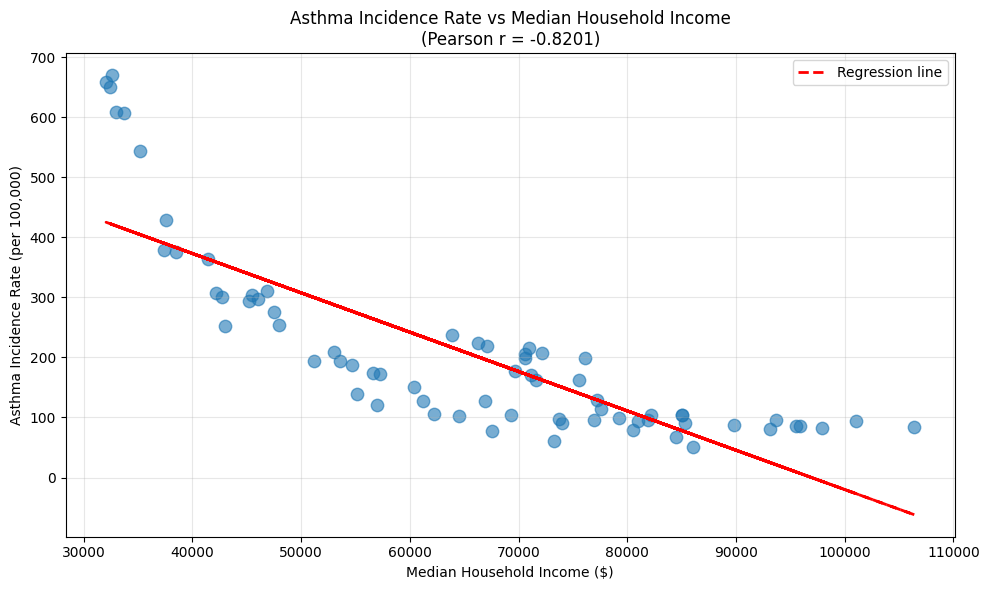

In [3]:
# Create a scatter plot with regression line
plt.figure(figsize=(10, 6))

plt.scatter(merged_corr["median_hh_income"], merged_corr["asthma_incidence_rate"], alpha=0.6, s=80)

# Add regression line
z = np.polyfit(merged_corr["median_hh_income"], merged_corr["asthma_incidence_rate"], 1)
p = np.poly1d(z)
plt.plot(merged_corr["median_hh_income"], p(merged_corr["median_hh_income"]), "r--", linewidth=2, label=f"Regression line")

plt.xlabel("Median Household Income ($)")
plt.ylabel("Asthma Incidence Rate (per 100,000)")
plt.title(f"Asthma Incidence Rate vs Median Household Income\n(Pearson r = {corr_value:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Pearson correlation between asthma_incidence_rate and pct_below_poverty: 0.8850


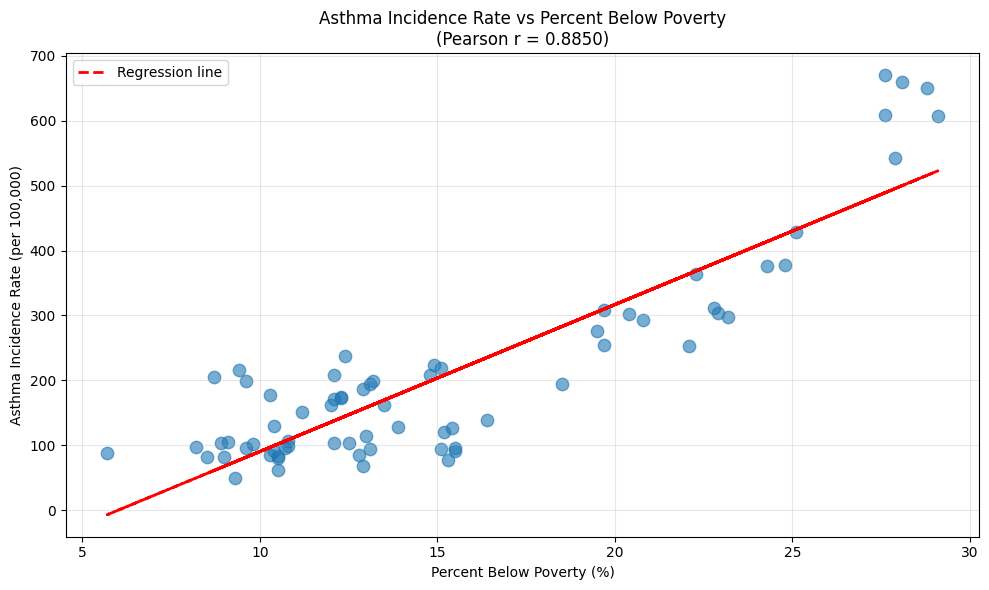

In [4]:
# Correlation between asthma_incidence_rate and pct_below_poverty
acs_poverty_subset = df[[time_col, borough_col, value_col]].copy()
asthma_subset = asthma_df[[asthma_year_col, asthma_borough_col, asthma_rate_col]].copy()

acs_poverty_subset[borough_col] = acs_poverty_subset[borough_col].astype(str).str.strip().str.lower()
asthma_subset[asthma_borough_col] = asthma_subset[asthma_borough_col].astype(str).str.strip().str.lower()

merged_poverty_corr = pd.merge(
    asthma_subset.rename(columns={asthma_year_col: "year", asthma_borough_col: "borough", asthma_rate_col: "asthma_incidence_rate"}),
    acs_poverty_subset.rename(columns={time_col: "year", borough_col: "borough"}),
    on=["year", "borough"],
    how="inner"
).dropna(subset=["asthma_incidence_rate", value_col])

corr_poverty = merged_poverty_corr["asthma_incidence_rate"].corr(merged_poverty_corr[value_col])

print(f"Pearson correlation between asthma_incidence_rate and {value_col}: {corr_poverty:.4f}")

# Create scatter plot with regression line
plt.figure(figsize=(10, 6))

plt.scatter(merged_poverty_corr[value_col], merged_poverty_corr["asthma_incidence_rate"], alpha=0.6, s=80)

# Add regression line
z = np.polyfit(merged_poverty_corr[value_col], merged_poverty_corr["asthma_incidence_rate"], 1)
p = np.poly1d(z)
plt.plot(merged_poverty_corr[value_col], p(merged_poverty_corr[value_col]), "r--", linewidth=2, label="Regression line")

plt.xlabel("Percent Below Poverty (%)")
plt.ylabel("Asthma Incidence Rate (per 100,000)")
plt.title(f"Asthma Incidence Rate vs Percent Below Poverty\n(Pearson r = {corr_poverty:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()